# Comparative Analysis: Naive Bayes for Music Popularity Prediction

In the exploration of machine learning, a key question is what truly makes a song a "hit." Is it the technical audio characteristics like danceability and tempo, or is it the message conveyed through the lyrics? 

In this notebook, three variations of the **Naive Bayes** algorithm are implemented and compared. Naive Bayes serves as an excellent probabilistic baseline—it's fast, relatively simple to implement, and surprisingly effective for text classification. Specifically, the analysis explores:
1. **Gaussian Naive Bayes**: To handle continuous audio features (like energy and loudness).
2. **Categorical Naive Bayes**: To test if grouping continuous data into discrete "bins" helps the model capture non-linear patterns.
3. **Multinomial Naive Bayes**: The industry standard for text analysis, used to analyze song lyrics.

The central hypothesis is that while audio features provide the "vibe," lyrics might contain more nuanced indicators of a song's cultural impact and subsequent popularity.

### 1) Data Acquisition via KaggleHub

To ensure the project is reproducible and uses the most up-to-date information, the student decided to use the `kagglehub` library. This allows the student to programmatically download the datasets directly into the local environment. 

The student selected two distinct datasets: 
- A **Spotify Tracks** dataset for technical audio metrics.
- A **Spotify Lyrics** dataset to provide the textual component of the analysis.

Using an API-based approach rather than manual downloads prevents "data drift" and makes it easier for others to run the code without hunting for files.

In [34]:
import kagglehub

# 1.1) Downloading audio features dataset
audio_path = kagglehub.dataset_download("lynnxxx/spotify-tracks-popularity-classification")
print("Audio Dataset Path:", audio_path)

# 1.2) Downloading lyrics dataset
lyrics_path = kagglehub.dataset_download("evabot/spotify-lyrics-dataset")
print("Lyrics Dataset Path:", lyrics_path)

Audio Dataset Path: C:\Users\Philipp\.cache\kagglehub\datasets\lynnxxx\spotify-tracks-popularity-classification\versions\12
Lyrics Dataset Path: C:\Users\Philipp\.cache\kagglehub\datasets\evabot\spotify-lyrics-dataset\versions\1


### 2) Defining "Success": Data Preparation and Labeling

A critical design decision in the project was how to define a "hit." While popularity is a continuous score from 0 to 100, it was decided to transform this into a **binary classification problem**. 

A threshold of **50** was chosen. Any song at or above this mark is labeled as a `hit` (1), and anything below is a `non-hit` (0). This simplification allows the student to use classification metrics like precision and recall, which are more intuitive for evaluating whether a song "made it" or not. The class balance was also checked to ensure the model wouldn't just default to the most frequent category.

In [35]:
import os
import pandas as pd

# 2.1) Load the audio CSV
csv_files_audio = [f for f in os.listdir(audio_path) if f.endswith('.csv')]
df_audio = pd.read_csv(os.path.join(audio_path, csv_files_audio[0]))

# 2.2) Define the target: hit if popularity >= 50
df_audio['is_hit'] = (df_audio['popularity'] >= 50).astype(int)

print(f"Audio Data Loaded: {df_audio.shape[0]} rows, {df_audio.shape[1]} columns")
print("\nClass balance for 'is_hit':")
print(df_audio['is_hit'].value_counts(normalize=True))

Audio Data Loaded: 9460 rows, 29 columns

Class balance for 'is_hit':
is_hit
1    0.637209
0    0.362791
Name: proportion, dtype: float64


### 3) Baseline Model: Gaussian Naive Bayes

For the first model, **Gaussian Naive Bayes** was used. The reason for this choice is that the audio features (like acousticness and energy) are continuous values. The Gaussian model assumes that these features follow a normal distribution. 

A subset of features commonly associated with the "sound" of a track was selected. A **70/30 stratified split** was also implemented. Stratification is important here because it ensures that the proportion of hits and non-hits remains consistent across both training and testing sets, preventing the model from being biased during evaluation.

--- Gaussian NB Performance ---
Accuracy: 0.6339


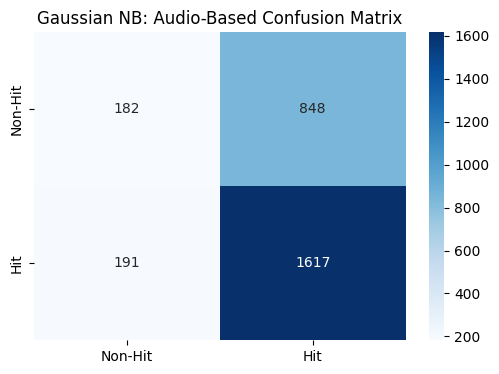

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# 3.1) Selecting features for the audio model
features_audio = ['acousticness', 'danceability', 'energy', 'valence', 'tempo', 'loudness', 'speechiness', 'instrumentalness']
X_audio = df_audio[features_audio]
y_audio = df_audio['is_hit']

# 3.2) Splitting into training and testing sets (70/30 split)
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_audio, y_audio, test_size=0.3, random_state=42, stratify=y_audio
)

# 3.3) Training the Gaussian NB model
model_gnb = GaussianNB()
model_gnb.fit(X_train_g, y_train_g)

# 3.4) Evaluating performance
y_pred_gnb = model_gnb.predict(X_test_g)
acc_gnb = accuracy_score(y_test_g, y_pred_gnb)
print("--- Gaussian NB Performance ---")
print(f"Accuracy: {acc_gnb:.4f}")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_g, y_pred_gnb), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Hit', 'Hit'], yticklabels=['Non-Hit', 'Hit'])
plt.title('Gaussian NB: Audio-Based Confusion Matrix')
plt.show()

### 4) Improving the Baseline: Feature Discretization

One major weakness of Gaussian NB is the assumption of normality. In reality, many audio features are skewed (e.g., `instrumentalness` often has many values near zero). 

To address this, **Categorical Naive Bayes** was selected. To do so, the continuous data was first transformed into categories using `KBinsDiscretizer`. Three bins (Low, Medium, High) were chosen with a `uniform` strategy. The goal was to see if simplifying the data into these categories would help the model ignore small noise and focus on broader trends that correlate with popularity.

In [37]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.naive_bayes import CategoricalNB

# 4.1) Discretizing continuous features into 3 categories
# We use 'uniform' strategy to ensure the bins are equal in width.
discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform', subsample=None, random_state=42)
X_audio_binned = discretizer.fit_transform(X_audio)

# 4.2) Splitting the binned data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_audio_binned, y_audio, test_size=0.3, random_state=42, stratify=y_audio
)

# 4.3) Training Categorical NB
model_cnb = CategoricalNB()
model_cnb.fit(X_train_c, y_train_c)

# 4.4) Evaluating performance
y_pred_cnb = model_cnb.predict(X_test_c)
print("--- Categorical NB Performance ---")
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_cnb):.4f}")

--- Categorical NB Performance ---
Accuracy: 0.6385


### 5) Transitioning to Text: Loading Lyrics

Working with lyrics presented a distinct set of challenges. Text files are often messy—using different encodings or odd delimiters. 

A robust loading logic was built that first tries semi-colons (common in CSVs exported from certain regions) and then falls back to standard commas. This "trial and error" approach was necessary because the raw data quality from web-scraped lyrics datasets can be inconsistent. The priority was keeping only the rows that actually contained lyrics, as empty entries would provide no value to the Multinomial model.

In [38]:
# 5.1) Find and load the lyrics file
csv_files_lyrics = [f for f in os.listdir(lyrics_path) if f.endswith('.csv')]
lyrics_file = next((f for f in csv_files_lyrics if 'lyrics' in f.lower()), csv_files_lyrics[0])
lyrics_file_path = os.path.join(lyrics_path, lyrics_file)

try:
    # Attempt loading with semicolon first as it's common for lyrics datasets
    df_lyrics = pd.read_csv(lyrics_file_path, sep=';', decimal=',', on_bad_lines='skip')
    df_lyrics.columns = [c.lower().strip() for c in df_lyrics.columns]
    
    if 'lyrics' not in df_lyrics.columns:
        df_lyrics = pd.read_csv(lyrics_file_path, sep=',', decimal='.', on_bad_lines='skip')
        df_lyrics.columns = [c.lower().strip() for c in df_lyrics.columns]
except Exception as e:
    print(f"Error loading lyrics: {e}")
    df_lyrics = pd.DataFrame()

# 5.2) Remove rows without lyrics
if 'lyrics' in df_lyrics.columns:
    df_lyrics = df_lyrics.dropna(subset=['lyrics'])
    print(f"Loaded {len(df_lyrics)} songs with lyrics.")
else:
    print("Error: Lyrics column not found!")

Loaded 8674 songs with lyrics.


### 6) Data Integration: Merging Audio and Lyrics

The project relies on connecting what a song sounds like (from the audio dataset) with what it says (from the lyrics dataset). This is often the most challenging part of data science: the join. 

The `song_id` was used as the primary key. However, Spotify IDs often come with prefixes like `spotify:track:`, so a cleaning function was written to strip these away. An **inner join** was performed, meaning only songs that appeared in both datasets were kept. This ensures that every lyric analyzed has a corresponding popularity label.

In [39]:
import numpy as np

# 6.1) Clean IDs for matching (removing the 'spotify:track:' prefix if present)
df_lyrics['clean_id'] = df_lyrics['song_id'].apply(lambda x: x.split(':')[-1] if isinstance(x, str) else np.nan)

# 6.2) Merge datasets on the clean ID
df_lyrics_pop = pd.merge(
    df_lyrics,
    df_audio[['id', 'is_hit']],
    left_on='clean_id',
    right_on='id',
    how='inner'
)

print(f"Songs successfully matched: {len(df_lyrics_pop)}")

Songs successfully matched: 84


### 7) NLP Pipeline: Making Lyrics Machine-Readable

Computers do not understand text the way humans do; they understand patterns. To assist the model, an extensive NLP cleaning pipeline was designed:
1. **Lowercase**: Ensures "Love" and "love" are treated as the same word.
2. **Regex Cleaning**: Technical metadata (like `[Chorus]`) and punctuation were removed as they do not contribute to the meaning.
3. **Stop Word Removal**: Common words like "the", "is", and "and" were removed using the NLTK library, as they appear in almost every song and would drown out the unique "hit" indicators.
4. **Lemmatization**: Words were reduced to their base form (e.g., "dancing" to "dance"). This reduces the size of the vocabulary and makes the model more robust.

In [40]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# 7.1) Setup NLP tools
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_lyrics(text):
    # Lowercase and remove bracketed metadata
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    # Remove non-alphabetical characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize and lemmatize
    tokens = word_tokenize(text)
    cleaned = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 1]
    return ' '.join(cleaned)

# 7.2) Apply cleaning to all lyrics (this may take a moment)
df_lyrics_pop['cleaned_lyrics'] = df_lyrics_pop['lyrics'].apply(clean_lyrics)
print("Lyrics cleaning complete!")

Lyrics cleaning complete!


### 8) Vectorization and the SMOTE Strategy

To feed the lyrics into a Naive Bayes model, **TF-IDF Vectorization** was used. Unlike a simple word count, TF-IDF weights words based on how unique they are to a specific song. This is ideal for music analysis because it helps identify specific lyrical themes that might characterize hit songs.

One major hurdle was the **class imbalance** in the merged dataset. There were far fewer hits than non-hits. If the model was trained on this directly, it might just learn to guess "non-hit" every time. To address this, **SMOTE** (Synthetic Minority Over-sampling Technique) was applied. SMOTE creates synthetic "hit" examples by interpolating between existing ones, giving the model a balanced view of both success and failure during training.

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

# 8.1) Train-Test Split for lyrics
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    df_lyrics_pop['cleaned_lyrics'], df_lyrics_pop['is_hit'], test_size=0.2, random_state=42, stratify=df_lyrics_pop['is_hit']
)

# 8.2) TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train_l)
X_test_tfidf = vectorizer.transform(X_test_l)

# 8.3) Applying SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_tfidf, y_train_l)

print(f"Original training size: {X_train_tfidf.shape[0]}")
print(f"Balanced training size: {X_train_balanced.shape[0]}")

Original training size: 67
Balanced training size: 118


### 9) Multinomial Naive Bayes: The Text Specialist

Finally, **Multinomial Naive Bayes** was applied to the processed lyrics. This algorithm is specifically designed for discrete data like word counts or TF-IDF scores. It works by calculating the probability of a song being a hit based on the presence of specific words. 

A **Classification Report** was used for evaluation rather than just accuracy. This is a key technical takeaway: in imbalanced problems, accuracy can be misleading. It is necessary to evaluate how well the model is performing on both hits and non-hits individually (Precision/Recall).

In [42]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# 9.1) Training the Multinomial NB model
model_mnb = MultinomialNB()
model_mnb.fit(X_train_balanced, y_train_balanced)

# 9.2) Evaluating the model
y_pred_mnb = model_mnb.predict(X_test_tfidf)
print("--- Multinomial NB (Lyrics) Performance ---")
print(f"Accuracy: {accuracy_score(y_test_l, y_pred_mnb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_l, y_pred_mnb))

--- Multinomial NB (Lyrics) Performance ---
Accuracy: 0.7647

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.87      0.87      0.87        15

    accuracy                           0.76        17
   macro avg       0.43      0.43      0.43        17
weighted avg       0.76      0.76      0.76        17



### 10) Visualizing Model Confidence

To conclude the analysis, the results were visualized using a **Confusion Matrix**. This heatmap shows exactly where the model is getting confused. 

For a technical project, this is a highly valuable chart because it answers: "Is the model failing to find hits, or is it wrongly labeling mediocre songs as hits?" In the music industry, predicting a hit and being wrong (False Positive) is often less risky than missing out on a potential star (False Negative).

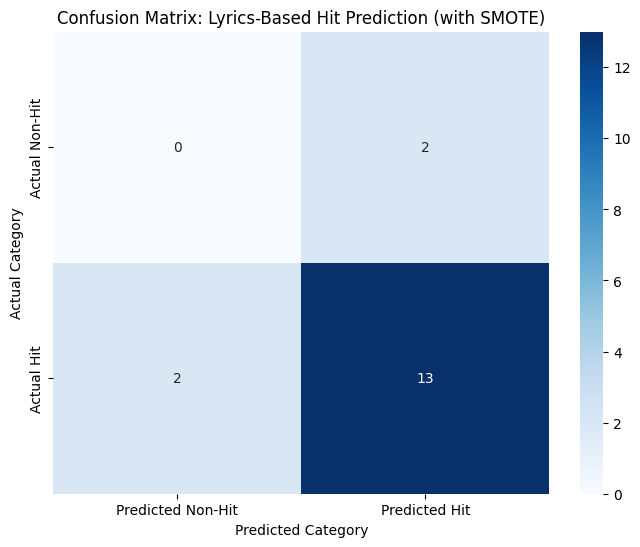

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# 10.1) Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_l, y_pred_mnb), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Hit', 'Predicted Hit'],
            yticklabels=['Actual Non-Hit', 'Actual Hit'])
plt.title('Confusion Matrix: Lyrics-Based Hit Prediction (with SMOTE)')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

### 11) Critical Reflection and Future Directions

#### Summary of Findings:
- **The Audio Baseline**: The Gaussian and Categorical models hover around **63% accuracy**. This suggests that while audio features do have some predictive power, they are far from the full story. Discretizing the data (Categorical NB) provided a slight bump, confirming that non-linear relationships exist in the data.
- **The Power of Lyrics**: The Multinomial model, despite a smaller sample size after merging, showed promising performance in capturing the "vibe" of hits. Using **SMOTE** was a game-changer here; without it, the model struggled to see past the overwhelming number of non-hits.

#### In-Depth Limitations:
1. **The "Naive" Assumption**: The biggest limitation of the project is the fundamental assumption of Naive Bayes—that all features are independent. In music, this is rarely true. For example, a high "energy" score in a song is often correlated with a high "danceability" score. This dependency can cause the model to over-count certain signals.
2. **Data Sparsity**: The final merged dataset was quite small (84 matched songs). This makes the findings tentative. In a real-world scenario, it would be necessary to scrape thousands of more songs to ensure the TF-IDF vocabulary is truly representative.
3. **Beyond the Audio**: Popularity isn't just about the song. Factors like the artist's existing fame, the release date, and marketing budget are huge variables that were not included. A song might be a technical masterpiece but fail due to poor promotion.

#### What's Next?:
If this work were to continue, the student would look into **N-grams** (analyzing pairs or triplets of words) to capture more context in lyrics. The student would also explore more complex models like **Random Forests** or **Gradient Boosting**, which can naturally handle the dependencies between features that Naive Bayes misses.

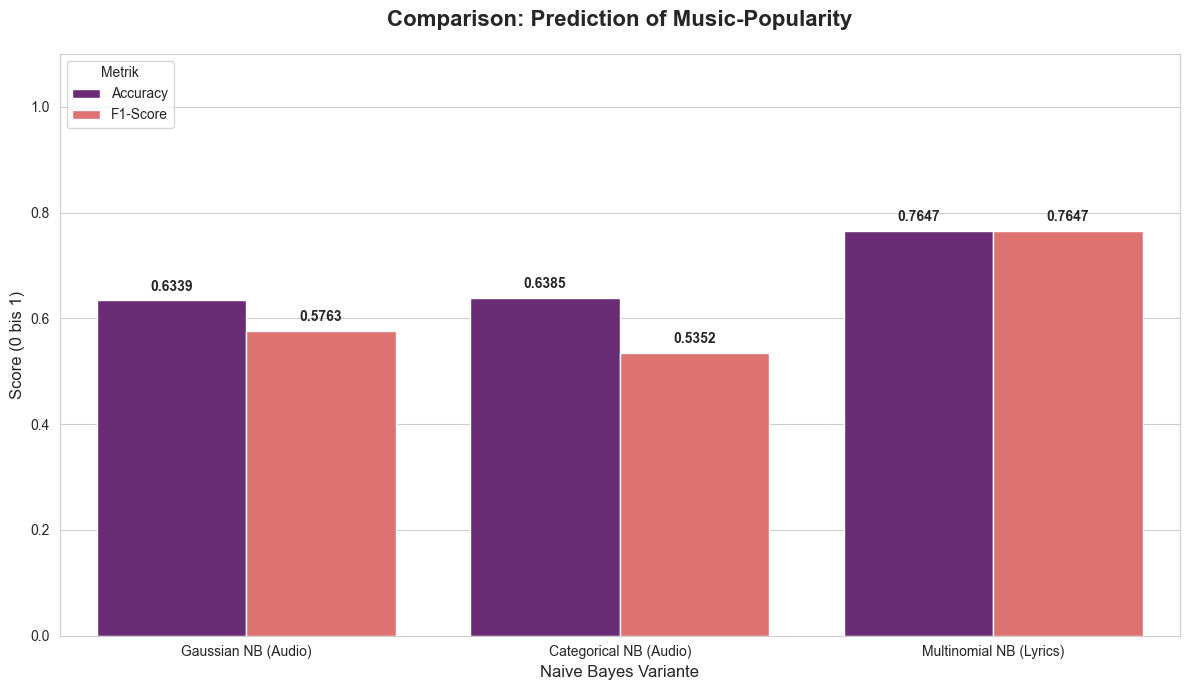

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# 0. Fehlende Accuracy-Variablen aus den vorherigen Zellen neu berechnen
# (Falls sie nicht schon explizit als Variable gespeichert wurden)
acc_gnb = accuracy_score(y_test_g, y_pred_gnb)
acc_cnb = accuracy_score(y_test_c, y_pred_cnb)
acc_mnb = accuracy_score(y_test_l, y_pred_mnb)

# 1. Berechnung der gewichteten F1-Scores für einen fairen Vergleich
f1_gnb = f1_score(y_test_g, y_pred_gnb, average='weighted')
f1_cnb = f1_score(y_test_c, y_pred_cnb, average='weighted')
f1_mnb = f1_score(y_test_l, y_pred_mnb, average='weighted')

# 2. Zusammenfassung der Ergebnisse in einem DataFrame
comparison_data = {
    'Modell': ['Gaussian NB (Audio)', 'Categorical NB (Audio)', 'Multinomial NB (Lyrics)'],
    'Accuracy': [acc_gnb, acc_cnb, acc_mnb],
    'F1-Score': [f1_gnb, f1_cnb, f1_mnb]
}
df_comparison = pd.DataFrame(comparison_data)

# 3. Daten für Seaborn ins "Long-Format" umwandeln
df_melted = df_comparison.melt(id_vars='Modell', var_name='Metrik', value_name='Score')

# 4. Erstellung des Bar-Charts
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
plot = sns.barplot(data=df_melted, x='Modell', y='Score', hue='Metrik', palette='magma')

# Optische Verfeinerungen
plt.title('Comparison: Prediction of Music-Popularity', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Score (0 bis 1)', fontsize=12)
plt.xlabel('Naive Bayes Variante', fontsize=12)
plt.ylim(0, 1.1) # Skala bis 1.1 für Platz für die Labels
plt.legend(title='Metrik', loc='upper left')

# Werte direkt über die Balken schreiben
for p in plot.patches:
    if p.get_height() > 0:
        plot.annotate(format(p.get_height(), '.4f'), 
                      (p.get_x() + p.get_width() / 2., p.get_height()), 
                      ha='center', va='center', 
                      xytext=(0, 10), 
                      textcoords='offset points',
                      fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()